### 딥러닝
- 딥러닝이란?
 - 인간의 신경망을 모방하여 학습하고 예측하는 기술
 - 대량의 데이터에서 복잡한 패턴, 규칙을 찾아내는 능력이 뛰어나다.
 - 머신러닝에 비해 다양한 상황 또는 유연한 사고가 가능하다. (사람처럼)
 - 인간의 뉴런 == 딥러닝 선형모델
 - 주로 컴퓨터비전, 잔여어처리, 음성분석 등에 많이 사용된다.

### 머신러닝과 딥러닝 사용법 사이
 - 머신러닝
   - 모델을 불러오는 작업 (완성된 객체) => 모델 학습 => 모델 예측 => 모델 평가
   - 완제품 로봇에서 팔이나 다리를 움직이는 정도를 조절가능하다.

 - 딥러닝
   - 모델을 불러오는 작업 (모델을 우리가 직접 설계 및 구성이 가능하다.) => 모델 학습 => 모델 예측 => 모델 평가
   - 부품을 통해 우리가 직접 로봇을 조립하여 원하는 모양의 로봇을 만들 수 있다.

In [1]:
# 드라이브 마운트

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 현재 내 경로 확인 방법

!pwd

/content


In [3]:
# 내가 사용할 폴더 경로 연결

%cd /content/drive/MyDrive/Colab Notebooks/딥러닝

/content/drive/MyDrive/Colab Notebooks/딥러닝


In [4]:
# 현재 내 경로 확인

!pwd

/content/drive/MyDrive/Colab Notebooks/딥러닝


In [5]:
# 라이브러리 불러오기

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# 데이터 불러오기

data = pd.read_csv('./data/student-mat.csv', delimiter=';')
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [7]:
# 데이터 정보 확인

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

| 컬럼 이름       | 설명                             |
|-----------------|----------------------------------|
| school          | 학교 (GP - Gabriel Pereira, MS - Mousinho da Silveira) |
| sex             | 성별 (F - Female, M - Male)      |
| age             | 나이                             |
| address         | 주소 유형 (U - Urban, R - Rural) |
| famsize         | 가족 크기 (LE3 - 3명 이하, GT3 - 3명 초과) |
| Pstatus         | 부모 동거 상태 (T - 함께, A - 별거) |
| Medu            | 어머니 교육 수준 (0 - 없음, 1 - 초등, 2 - 중등, 3 - 고등, 4 - 대졸) |
| Fedu            | 아버지 교육 수준 (0 - 없음, 1 - 초등, 2 - 중등, 3 - 고등, 4 - 대졸) |
| Mjob            | 어머니 직업 (teacher, health, services, at_home, other) |
| Fjob            | 아버지 직업 (teacher, health, services, at_home, other) |
| reason          | 학교 선택 이유 (home, reputation, course, other) |
| guardian        | 보호자 (mother, father, other)  |
| traveltime      | 통학 시간 (1 - 15분 이하, 2 - 15~30분, 3 - 30분~1시간, 4 - 1시간 초과) |
| studytime       | 주간 공부 시간 (1 - 2시간 이하, 2 - 2~5시간, 3 - 5~10시간, 4 - 10시간 초과) |
| failures        | 과목 낙제 수 (n if 1<=n<3, else 4) |
| schoolsup       | 학교 추가 지원 (yes, no)        |
| famsup          | 가족 추가 지원 (yes, no)        |
| paid            | 과외 수업 참여 (yes, no)        |
| activities      | 학교 외 활동 참여 (yes, no)     |
| nursery         | 유치원 참여 여부 (yes, no)      |
| higher          | 고등교육 희망 여부 (yes, no)    |
| internet        | 가정 내 인터넷 접속 여부 (yes, no) |
| romantic        | 로맨틱 관계 여부 (yes, no)      |
| famrel          | 가족 관계의 질 (1 - 매우 나쁨, 5 - 매우 좋음) |
| freetime        | 여가 시간의 양 (1 - 매우 적음, 5 - 매우 많음) |
| goout           | 외출 빈도 (1 - 매우 적음, 5 - 매우 많음) |
| Dalc            | 평일 음주량 (1 - 매우 적음, 5 - 매우 많음) |
| Walc            | 주말 음주량 (1 - 매우 적음, 5 - 매우 많음) |
| health          | 현재 건강 상태 (1 - 매우 나쁨, 5 - 매우 좋음) |
| absences        | 결석 일수                        |
| G1              | 1학기 성적                       |
| G2              | 2학기 성적                       |
| G3              | 최종 성적                        |


### 데이터 분리
- X데이터(문제데이터) / y(정답데이터) 분리하기
- train, test 분

In [8]:
# 문제데이터와 정답데이터 분리
# X => studytime.freetime 만 사용
# y => G3

X = data[['studytime', 'freetime']]
y = data['G3']

In [9]:
# train / test 나누기
# 분할할 수 있도록 도구 불러오기

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 5, test_size = 0.3)

In [10]:
# 크기확인

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

# 1. 문제의 수와 정답의 수가 같은지 확인
# 2. 훈련용 데이터와 테스트용 데이터의 입력특성의 수가 같은지 확인

(276, 2)
(119, 2)
(276,)
(119,)


### 머신러닝 사용하기 (회귀)
 - LinearRegression 모델 사용

In [11]:
# 머신러닝 모델 도구 불러오기

from sklearn.linear_model import LinearRegression   # LinearRegression 도구
from sklearn.metrics import mean_squared_error   # MSE 확인 도구


# 모델 객체 생성

linear_model = LinearRegression()


# 모델 학습

linear_model.fit(X_train, y_train)


# 모델 평가

linear_model.score(X_test, y_test)

-0.005807850525840097

In [12]:
# MSE 확인 (평균제곱오차)

pre = linear_model.predict(X_test)

mse = mean_squared_error(y_test, pre)
mse

21.72675646101634

### 딥러닝 모델 사용
 - TensorFlow 사용하기
   - 신경망 구조 설계
   - 학습 방법 설정
   - 학습
   - 예측 및 평가

In [13]:
# 도구 불러오기

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer
from tensorflow.keras.layers import Dense

# Sequntial : 뼈대를 생성하는 도구
# InputLayer : 입력층을 쌓을 때 사용하는 도구 중 하나 (하나만 있는것이 아님)
# Dense : 은닉층(중간층), 출력층을 쌓을 때 사용하는 도구

### 딥러닝 구조
 - Sequential : 뼈대를 구축
 - 입력층 : 데이터가 들어오는 층
 - 중간층(은닉층) : 실제 학습이 진행되는 층 (예측을 위하여 여러가지 계산이 진행) => 실제 성능과 연관이 있는 층
 - 출력층 : 결과를 예측하는 층

In [14]:
# 신경망 구조 설계 진행
# 1. 뼈대 생성

model = Sequential()


# 입력층 쌓기

model.add(InputLayer(shape=(2,)))   # 입력특성 2개


# 중간층(은닉층)쌓기 => 학습의 성능을 설정하는 층

model.add(Dense(units=10, activation = 'sigmoid'))

# unit : 퍼셉트론(신경망)의 개수 설정 => 많으면 학습능력이 올라갈 수 있음 (무조건은 아님)
# activation : 활성화 함수 => 사람처럼 생각할 수 있도록 도와주는 기능


# 출력층 쌓기 => 결과를 출력하는 층

model.add(Dense(units = 1, activation='linear'))

# 출력층은 내가 예측하고자 하는 Label에 따라 다르게 설정
# 회귀문제일 경우 unit의 개수는 1개 / activation = 'linear'
# 이진분류일 경우 unit의 개수는 1개 / activation = 'sigmoid'
# 다중분류일 경우 unit의 개수는 Class의 개수만큼 / activation = 'softmax'

In [15]:
# 2. 학습방법 및 평가 방법 설정

model.compile(
    loss = 'mean_squared_error',   # 오차 계산 방법
    optimizer = 'SGD',   # 최적화 함수 => 오차를 줄여나가는 방법 (경사하강법)
    metrics = ['mse']   # 평가지표 (우선은 MSE로 평가)
)

In [16]:
# 3. 신경망 모델 학습

his = model.fit(X_train, y_train, validation_split = 0.2, epochs = 20)

# validation_split : 검증용 데이터 분리
# epochs : 학습 회수

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 80.5419 - mse: 80.5419 - val_loss: 41.3680 - val_mse: 41.3680
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 28.6831 - mse: 28.6831 - val_loss: 23.6241 - val_mse: 23.6241
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 21.8959 - mse: 21.8959 - val_loss: 21.2564 - val_mse: 21.2564
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 21.2048 - mse: 21.2048 - val_loss: 20.8528 - val_mse: 20.8528
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 21.1357 - mse: 21.1357 - val_loss: 20.7393 - val_mse: 20.7393
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 21.0691 - mse: 21.0691 - val_loss: 20.7831 - val_mse: 20.7831
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 20.9452 - mse: 20.9452 - val_loss: 20.8358 - val_mse: 20.8358
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 21.0891 - mse: 21.0891 - val_loss: 20.8734 - val_mse: 20.8734
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

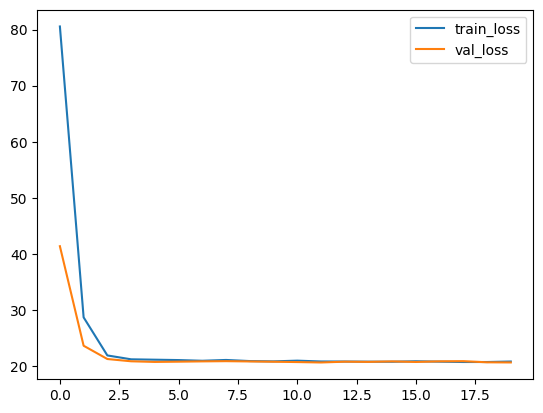

In [17]:
# 학습 결과 시각화

plt.plot(his.history['loss'], label = 'train_loss')
plt.plot(his.history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()

### 입력특성을 전체 데이터로 설정
 - school ~ G2 : 문제 데이터
 - G3 : 정답 데이터

In [18]:
data.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [20]:
# 데이터 분할

X = data.loc[ : , 'school' : 'G2']
y = data['G3']

In [21]:
# 문제 데이터 원핫인코딩

X_oh = pd.get_dummies(X, dtype = 'int')
X_oh

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,activities_no,activities_yes,nursery_no,nursery_yes,higher_no,higher_yes,internet_no,internet_yes,romantic_no,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,1,0,0,1,0,1,1,0,1,0
1,17,1,1,1,2,0,5,3,3,1,...,1,0,1,0,0,1,0,1,1,0
2,15,1,1,1,2,3,4,3,2,2,...,1,0,0,1,0,1,0,1,1,0
3,15,4,2,1,3,0,3,2,2,1,...,0,1,0,1,0,1,0,1,0,1
4,16,3,3,1,2,0,4,3,2,1,...,1,0,0,1,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,20,2,2,1,2,2,5,5,4,4,...,1,0,0,1,0,1,1,0,1,0
391,17,3,1,2,1,0,2,4,5,3,...,1,0,1,0,0,1,0,1,1,0
392,21,1,1,1,1,3,5,5,3,3,...,1,0,1,0,0,1,1,0,1,0
393,18,3,2,3,1,0,4,4,1,3,...,1,0,1,0,0,1,0,1,1,0


In [22]:
# 데이터 분할

X_train, X_test, y_train, y_test = train_test_split(X_oh, y,
                                                    random_state = 3,
                                                    test_size = 0.3
                                                    )

In [23]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((276, 58), (119, 58), (276,), (119,))

In [24]:
# 신경망 구조 설계
# 뼈대 설정

model = Sequential()


# 입력층 설정

model.add(InputLayer(shape = (58, )))


# 은닉층 설정

model.add(Dense(units = 64, activation = 'sigmoid'))
model.add(Dense(units = 32, activation = 'sigmoid'))
model.add(Dense(units = 16, activation = 'sigmoid'))


# 출력층 설정

model.add(Dense(units = 1))

In [25]:
# 학습 및 평가방법 설정

model.compile(
    loss = 'mse',   # 손실 함수 - 어떻게 오류를 볼것인가?
    optimizer = 'SGD',   # 어떤 방법으로 모델을 최정화 시킬 것인가 (최적화 함수)
    metrics = ['mse']   # 어떤 지표로 모델을 평가할것인가?
)

In [26]:
# 모델 학습

model.fit(X_train, y_train,
          epochs = 20,   # 학습 반복 횟수
          validation_split = 0.2   # 교차검증 20%
          )

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 76.9170 - mse: 76.9170 - val_loss: 32.8307 - val_mse: 32.8307
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 23.8759 - mse: 23.8759 - val_loss: 23.0475 - val_mse: 23.0475
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 20.0342 - mse: 20.0342 - val_loss: 22.6809 - val_mse: 22.6809
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 19.9322 - mse: 19.9322 - val_loss: 22.5204 - val_mse: 22.5204
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 19.6155 - mse: 19.6155 - val_loss: 22.4008 - val_mse: 22.4008
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 19.4661 - mse: 19.4661 - val_loss: 22.1112 - val_mse: 22.1112
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 19.2425 - mse: 19.2425 - val_loss: 21.8156 - val_mse: 21.8156
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 19.0961 - mse: 19.0961 - val_loss: 21.5261 - val_mse: 21.5261
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

In [27]:
# 모델 평가

model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 10.6089 - mse: 10.6089


[10.608929634094238, 10.608929634094238]

In [28]:
np.sqrt(8.7812)

np.float64(2.963308961279603)